# McGill COMP551, MINI-PROJECT 3: Odd-One-Out Image Groups
Student names (IDs) - **Kaggle team name**


# Kaggle Competition
Training and test data are available as part of the assignment in the `datasets` folder. To participate in the competition you should upload a CSV file containing your predicted labels for the entire test data to Kaggle.

The test data is divided in half. You receive the correct labels for the first half (in the `datasets` folder), so that you can evaluate your model in this notebook on that part of the test set. You then submit your solution for the entire test set to Kaggle. The final evaluation is based on your predictions for the second half of the test set (private leaderboard). We have step-by-step explanation in the final section of this notebook.


# Report
The purpose of this notebook is for you to provide a concise high level code of your methodology. That is, you need to include all steps necessary to reproduce your results. Please include a high-level explanation of the implementation so that we can understand what you're trying to achieve in each piece of the code. You can import python code here if needed, in order to keep the notebook concise.

**Note:** You need to submit this notebook where you have run all the cells as part of the assignment. **We should not need to rerun your code since this can take a long time.** 


## Step 1 — The Dataset
Use the following code to load the data using the npy files. We have **3,000 training examples**, where each example is a group of **5 grayscale images** (each 32×32). In each group:
- **4 images** share a hidden common property, and
- **1 image** is the **outlier**.

You do **not** have access to the underlying attributes. Your task is to learn to identify the **index** of the outlier image (a 5-class classification problem, with labels in {0, 1, 2, 3, 4}). The label is printed above each group shown below.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.load('datasets/x_train.npy')  # (3000, 5, 32, 32) — 3000 groups of 5 images each
y = np.load('datasets/y_train.npy')  # (3000,) — index of the outlier image in each group (0-4)

print(f'Training set: {x.shape[0]} groups, each with {x.shape[1]} images of size {x.shape[2]}x{x.shape[3]}')
print(f'Labels: values in {np.unique(y)}')

ModuleNotFoundError: No module named 'matplotlib'

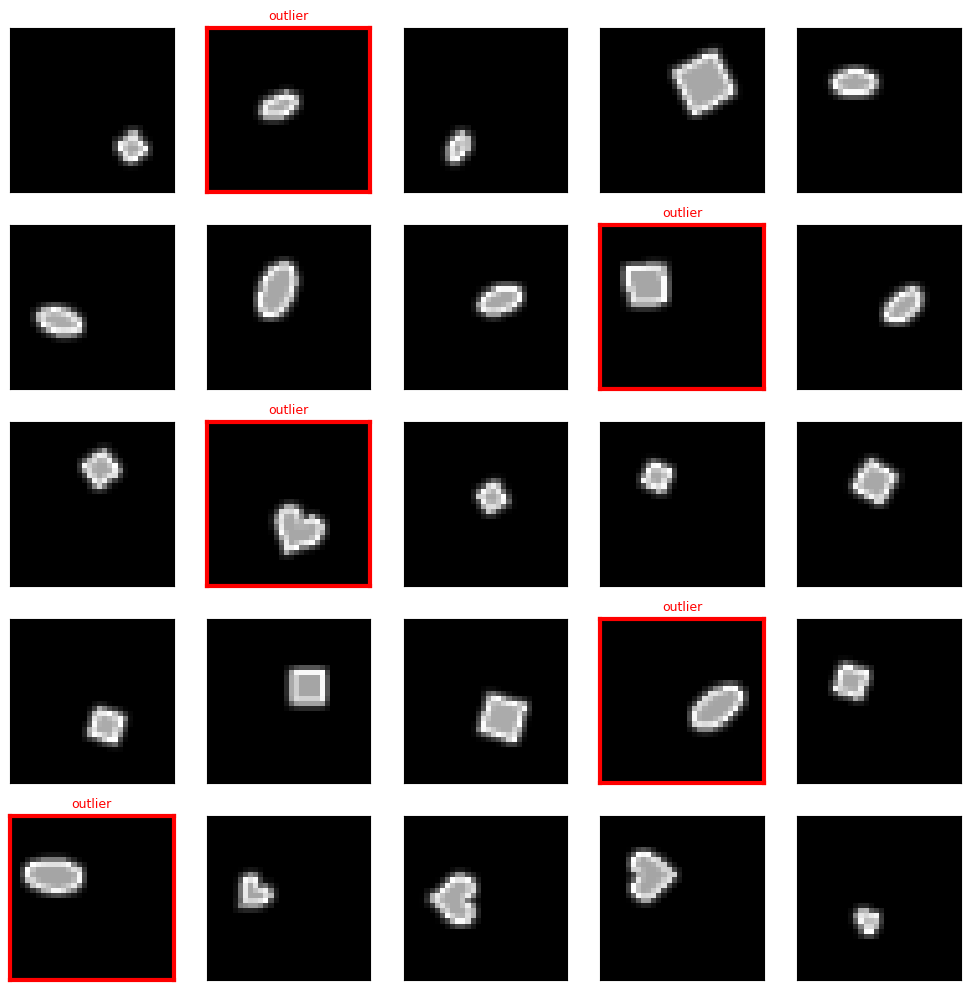

In [ ]:
def plot_groups(x, y, num_groups=5):
    """Plot groups of 5 images. The outlier is highlighted with a red border."""
    fig, axes = plt.subplots(num_groups, 5, figsize=(10, 2 * num_groups))
    for i in range(num_groups):
        for j in range(5):
            axes[i, j].imshow(x[i, j], cmap='gray')
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])
            if j == y[i]:
                for spine in axes[i, j].spines.values():
                    spine.set_edgecolor('red')
                    spine.set_linewidth(3)
                axes[i, j].set_title('outlier', color='red', fontsize=9)
    plt.tight_layout()
    plt.show()

plot_groups(x, y, num_groups=5)

## Step 2 — Example: Logistic Regression Baseline
Below we apply a simple logistic regression to the flattened input as a demonstration. This model treats the entire group of 5 images as one flat vector and does not use any deep learning.

Note that **random chance** for this 5-class problem is **20%** (1/5). 
As you can see, the logistic regression baseline performs close to random chance — you are expected to do significantly better using a deep learning model implemented in PyTorch (or Jax/TensorFlow).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

features = x.reshape(x.shape[0], -1)  # flatten each group of 5 images into a single vector
labels = y

x_train, x_val, y_train, y_val = train_test_split(features, labels, test_size=0.33, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(x_train, y_train)

predictions = clf.predict(x_val)
accuracy = accuracy_score(y_val, predictions)
print(f'The validation accuracy of the baseline model is {accuracy * 100:.2f}%')

NameError: name 'x' is not defined

## Step 3 — Your Model
This is the main part of your report. Provide your model implementation, training code, and explanation below. Details should include the architecture, choice of hyperparameters, and any preprocessing or augmentation you applied. If you performed a hyperparameter search, explain it here.

**Important:** Your model must have at most **25,000** trainable parameters. You **must** uncomment and run the cell below to print and verify the parameter count. This count must also appear in your report.

In [ ]:
## your implementation goes here!



In [ ]:
# ============================================================
# REQUIRED: Print the number of trainable parameters in your model.
# Replace `model` with the name of your PyTorch model.
# This cell MUST appear with its output in your submitted notebook.
# ============================================================

# total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f'Total trainable parameters: {total_params:,}')
# assert total_params <= 25_000, f'Model too large! {total_params:,} > 25,000'

## Step 4 — Accuracy Metrics and CSV Submission to Kaggle
At minimum, you **must** report in your submitted notebook:
1. The **number of trainable parameters** (printed in Step 3 above).
2. Your accuracy on the **first half of the test set** (public leaderboard).

**This accuracy must match your public leaderboard score on Kaggle.** If it does not, your leaderboard submission is discarded.

Below we show this evaluation for the logistic regression baseline. Note that the baseline accuracy is close to **random chance (20%)** — you should aim to do much better.

In [ ]:
x_test = np.load('datasets/x_test.npy')        # (2000, 5, 32, 32) — 2000 test groups
x_test_half = x_test[:1000]                     # first half: you have the true labels
y_test_half = np.load('datasets/y_test.npy')    # (1000,) — true labels for the first half only

print(f'Test set: {x_test.shape[0]} groups total')
print(f'Public half: {x_test_half.shape[0]} groups (labels provided)')
print(f'Private half: {x_test.shape[0] - x_test_half.shape[0]} groups (labels hidden)\n')

predictions = clf.predict(x_test_half.reshape(x_test_half.shape[0], -1))
accuracy = accuracy_score(y_test_half, predictions)
print(f'Public test accuracy (should match public leaderboard): {accuracy * 100:.2f}%')

Test set: 2000 groups total
Public half: 1000 groups (labels provided)
Private half: 1000 groups (labels hidden)

Public test accuracy (should match public leaderboard): 21.00%


In [ ]:
# ============================================================
# REQUIRED: Print your model's accuracy on the public test half.
# This number MUST match your public leaderboard score on Kaggle.
# Replace the code below with your own model's predictions.
# ============================================================

# your_predictions = ...  # your model's predictions on x_test_half
# your_accuracy = accuracy_score(y_test_half, your_predictions)
# print(f'Public test accuracy (must match Kaggle public leaderboard): {your_accuracy * 100:.2f}%')

### Generating the CSV for Kaggle Submission
In order to submit your results to Kaggle you need to provide your predictions in CSV format. The code below shows how to do this for the logistic regression baseline above. You can use the same method for your submission.

Note that you need to submit your result for the **entire test set** of size **2,000**. Your accuracy on the first 1,000 will show on the public leaderboard and the remaining 1,000 are on the private leaderboard that will be revealed when the competition is over. Submit the `predicted_labels.csv` to the Kaggle competition!

In [ ]:
import pandas as pd

def generate_csv_kaggle(y):
    indexes = np.arange(len(y))
    csv_labels = np.concatenate((indexes.reshape(-1, 1), y.reshape(-1, 1)), axis=1)
    df = pd.DataFrame(csv_labels, columns=['Id', 'Category'])
    df['Id'] = df['Id'].astype(str)
    df['Category'] = df['Category'].astype(str)
    df.to_csv('predicted_labels.csv', index=False)

# Baseline prediction for the entire test set (2000 groups)
yh_test = clf.predict(x_test.reshape(x_test.shape[0], -1))
generate_csv_kaggle(yh_test)
print(f'Saved {len(yh_test)} predictions to predicted_labels.csv')

Saved 2000 predictions to predicted_labels.csv
